In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

In [14]:
df = pd.read_csv("global_pharmacy_sales_2020_2025_daily_dataset.csv")

In [15]:
# select numerical columns
num = df.select_dtypes(include=np.number)

In [16]:
# check skewness of all numerical columns
skew_data = num.skew().sort_values(ascending=False)

print("\nreal skewness of numerical columns:")
print(skew_data)


real skewness of numerical columns:
units_sold               7.647395
covid_flag               0.706228
day                      0.006561
expiry_days_remaining    0.001331
year                    -0.000277
unit_price              -0.002948
month                   -0.009221
stock_level             -5.531067
dtype: float64


In [17]:
# find columns with high skewness
# abs means both positive and negative skewness
high_skew = skew_data[abs(skew_data) > 1]

print("\nhigh skewed columns:")
print(high_skew)


high skewed columns:
units_sold     7.647395
stock_level   -5.531067
dtype: float64


In [18]:
# show only the names of high skewed columns
print("\nhigh skewed column names:")
print(high_skew.index.tolist())


high skewed column names:
['units_sold', 'stock_level']


In [19]:
# make a copy of the data
df_log = df.copy()

In [20]:
# apply log transformation
# log1p means log(1 + value)

for col in high_skew.index:

# log transformation is safe for positive values
    if df[col].min() >= 0:
        df_log[col] = np.log1p(df[col])


# check skewness after log transformation
log_skew = df_log[high_skew.index].skew()

print("\nskewness after log transformation:")
print(log_skew)


skewness after log transformation:
units_sold      0.546841
stock_level   -28.266844
dtype: float64


In [21]:
# make a copy of the data
df_box = df.copy()

In [24]:
# apply box-cox transformation
# +1 makes the values positive
from scipy.stats import boxcox
# apply box-cox transformation
# +1 makes the values positive

for col in high_skew.index:

    value = df[col] + 1
    df_box[col], lam = boxcox(value)
    print("\nbox-cox lambda for", col, ":", lam)



box-cox lambda for units_sold : -0.2378901712029592

box-cox lambda for stock_level : 6.0708186599140115


In [25]:
# check skewness after box-cox
box_skew = df_box[high_skew.index].skew()

print("\nskewness after box-cox transformation:")
print(box_skew)


skewness after box-cox transformation:
units_sold    -0.039395
stock_level   -0.249316
dtype: float64


In [28]:
# make a copy of the data
df_yj = df.copy()

In [29]:
from scipy.stats import yeojohnson
# apply yeo-johnson transformation
for col in high_skew.index:
    df_yj[col], lam = yeojohnson(df[col])
    print("\nyeo-johnson lambda for", col, ":", lam)


yeo-johnson lambda for units_sold : -0.23789017724053135

yeo-johnson lambda for stock_level : 6.070820055482924


In [30]:
# check skewness after yeo-johnson
yj_skew = df_yj[high_skew.index].skew()

print("\nskewness after yeo-johnson transformation:")
print(yj_skew)


skewness after yeo-johnson transformation:
units_sold    -0.039395
stock_level   -0.249316
dtype: float64


In [31]:
# create comparison table
result = pd.DataFrame({
    "original": df[high_skew.index].skew(),
    "log": df_log[high_skew.index].skew(),
    "box_cox": df_box[high_skew.index].skew(),
    "yeo_johnson": df_yj[high_skew.index].skew()
})


# show comparison
print("\nskewness comparison:")
print(result)


skewness comparison:
             original        log   box_cox  yeo_johnson
units_sold   7.647395   0.546841 -0.039395    -0.039395
stock_level -5.531067 -28.266844 -0.249316    -0.249316


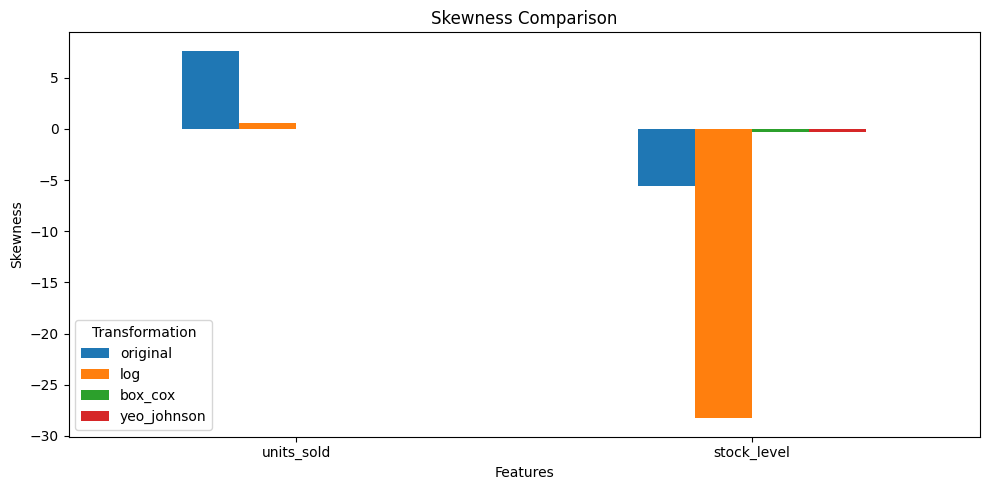

In [42]:
# Comparison graph
result.plot(kind='bar', figsize=(10, 5))

plt.title("Skewness Comparison")
plt.xlabel("Features")
plt.ylabel("Skewness")

plt.xticks(rotation=0)
plt.legend(title="Transformation")
plt.tight_layout()
plt.show()